# A06 — Cross-Dataset Transfer Learning (Optional Appendix K)
Covers Appendix K — low-resource and cross-dataset transfer analysis:
- Figure K1(a): Low-resource MRR@20 curves by transfer setting
- Figure K1(b): Relative gain over no-transfer baseline across data fractions
- Table K1: Full-data transfer summary by setting


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import appendix_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()


In [2]:
# appendix_transfer_summary.csv  cols: dataset, setting_key, setting_label, data_fraction, route_mrr20, baseline_mrr20
transfer_df = load_csv('appendix_transfer_summary.csv')
transfer_df['dataset_label'] = transfer_df['dataset'].map(dataset_label)
print(f"transfer_df: {transfer_df.shape}")
print("settings:  ", transfer_df['setting_label'].unique())
print("fractions: ", sorted(transfer_df['data_fraction'].unique()))


transfer_df: (25, 10)
settings:   ['Frozen router' 'Finetuned router' 'Anchor transfer' 'Full fine-tune'
 'No transfer (scratch)']
fractions:  [0.1, 0.25, 0.5, 0.75, 1.0]


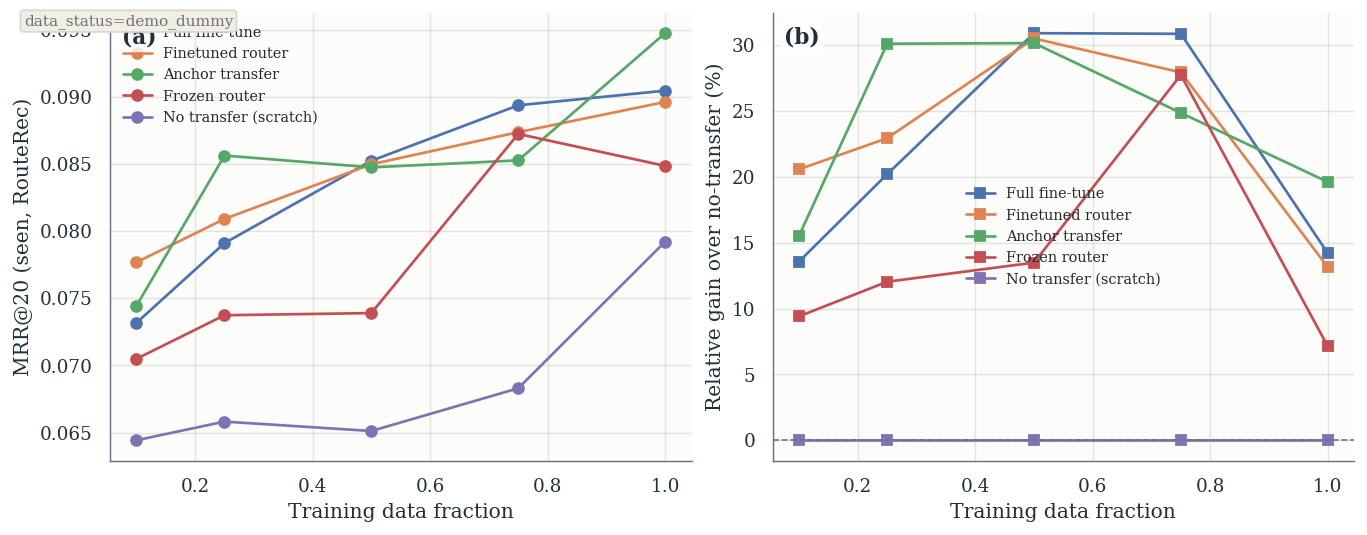

In [ ]:
# ── Figure K1(a) — Low-resource MRR@20 curves by transfer setting ──────────────
SETTINGS_ORDER = ['Full fine-tune', 'Finetuned router', 'Anchor transfer',
                  'Frozen router',  'No transfer (scratch)']
settings_present = [s for s in SETTINGS_ORDER if s in transfer_df['setting_label'].unique()]

fig, ax = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
for sl in settings_present:
    sub = (
        transfer_df[transfer_df['setting_label'] == sl]
        .groupby('data_fraction', as_index=False)['route_mrr20'].mean()
        .sort_values('data_fraction')
    )
    ax.plot(sub['data_fraction'], sub['route_mrr20'], marker='o', label=sl, linewidth=2.1, markersize=5.4)
ax.set_xlabel('Training data fraction')
ax.set_ylabel('MRR@20 (seen, RouteRec)')
ax.legend(fontsize=8)
clean_axes(ax)
annotate_demo(fig, transfer_df)
plt.show()


In [ ]:
# ── Figure K1(b) — Relative gain over no-transfer baseline across data fractions ──
no_transfer = (
    transfer_df[transfer_df['setting_label'] == 'No transfer (scratch)']
    .groupby('data_fraction', as_index=False)['route_mrr20'].mean()
    .sort_values('data_fraction')
    .set_index('data_fraction')['route_mrr20']
)

fig, ax = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
for sl in settings_present:
    sub = (
        transfer_df[transfer_df['setting_label'] == sl]
        .groupby('data_fraction', as_index=False)['route_mrr20'].mean()
        .sort_values('data_fraction')
    )
    gain = (sub.set_index('data_fraction')['route_mrr20'] - no_transfer) / no_transfer.clip(lower=1e-8) * 100
    ax.plot(gain.index, gain.values, marker='s', label=sl, linewidth=2.1, markersize=5.4)
ax.axhline(0, color=PALETTE['muted'], linewidth=0.9, linestyle='--')
ax.set_xlabel('Training data fraction')
ax.set_ylabel('Relative gain over no-transfer (%)')
ax.legend(fontsize=8)
clean_axes(ax)
annotate_demo(fig, transfer_df)
plt.show()


In [4]:
# ── Table K1 — Full-data transfer summary by setting ──────────────────────────
full_data = transfer_df[transfer_df['data_fraction'] == 1.0]
tbl = full_data.groupby('setting_label', as_index=False)[['route_mrr20', 'baseline_mrr20']].mean()
tbl['gain_%'] = (tbl['route_mrr20'] - tbl['baseline_mrr20']) / tbl['baseline_mrr20'].clip(lower=1e-8) * 100
tbl.columns = ['Transfer setting', 'RouteRec MRR@20', 'Baseline MRR@20', 'Gain (%)']

def bold_max(col):
    return ['font-weight: bold' if v == col.max() else '' for v in col]

display(
    tbl.style
    .apply(bold_max, subset=['RouteRec MRR@20', 'Gain (%)'])
    .format({'RouteRec MRR@20': '{:.4f}', 'Baseline MRR@20': '{:.4f}', 'Gain (%)': '{:.1f}'})
    .set_caption('Table K1 — Transfer setting comparison at full data fraction')
    .hide(axis='index')
)
annotate_demo(plt.gcf(), transfer_df)


Transfer setting,RouteRec MRR@20,Baseline MRR@20,Gain (%)
Anchor transfer,0.0947,0.0869,9.0
Finetuned router,0.0896,0.0900,-0.4
Frozen router,0.0849,0.0801,5.9
Full fine-tune,0.0905,0.0905,-0.0
No transfer (scratch),0.0792,0.0662,19.7


<Figure size 832x624 with 0 Axes>